In [1]:
import torch

In [2]:
t_c = torch.tensor([0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])

In [3]:
def model(t_u, w, b):
    return w * t_u + b

def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

In [4]:
w = torch.ones(())
b = torch.zeros(())

t_p = model(t_u, w, b)
t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

In [5]:
loss = loss_fn(t_p, t_c)
loss

tensor(1763.8848)

In [6]:
torch.ones(2, 1, 1)

tensor([[[1.]],

        [[1.]]])

In [7]:
y = torch.rand(3, 1)
z = torch.rand(1, 3)
y, z

(tensor([[0.7491],
         [0.7838],
         [0.5101]]),
 tensor([[0.6149, 0.4514, 0.3885]]))

In [8]:
y * z

tensor([[0.4606, 0.3382, 0.2911],
        [0.4819, 0.3538, 0.3045],
        [0.3136, 0.2302, 0.1982]])

## Градиентный спуск

In [9]:
delta = 0.1
loss_rate_of_change_w = (loss_fn(model(t_u, w + delta, b), t_c) - loss_fn(model(t_u, w - delta, b), t_c)) / (2. * delta)
loss_rate_of_change_w

tensor(4517.2974)

In [10]:
learning_rate = 1e-2 # скорость обучения

w = w - learning_rate * loss_rate_of_change_w
w

tensor(-44.1730)

In [11]:
loss_rate_of_change_b = (loss_fn(model(t_u, w, b + delta), t_c) - loss_fn(model(t_u, w, b - delta), t_c)) / (2. * delta)
b = b - learning_rate * loss_rate_of_change_b
b

tensor(46.)

In [12]:
# производная функции потерь
def dloss_fn(t_p, t_c):
    dsq_diffs = 2 * (t_p - t_c) / t_p.size(0) # t_p.size(0) получается из .ment()
    return dsq_diffs

Частные производные модели по параметрам w (weight) и b (bias):

In [13]:
# производная модели по w
def dmodel_dw(t_u, w, b):
    return t_u

def dmodel_db(t_u, w, b):
    return 1.0

In [14]:
# t_unknown, t_celsius, t_predict
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])

Подгонка в цикле

In [15]:
def training_loop(n_epoch, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epoch + 1):
        w, b = params

        t_p = model(t_u, w, b) # прямой проход
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b) # обратный проход

        params = params - learning_rate * grad

        print(f'Epoch {epoch}, Loss {float(loss)}')
        
    return params

In [16]:
t_un = 0.1 * t_u  # что-то типа нормализации, чтобы градиенты по переменным не сильно расходились

params = training_loop(
    n_epoch = 5000,
    learning_rate = 1e-2, # первое, что стоит настраивать, если получается мусор на выходе
    params = torch.tensor([1., 0.]),
    t_u = t_un,
    t_c = t_c)

Epoch 1, Loss 80.36434173583984
Epoch 2, Loss 37.574913024902344
Epoch 3, Loss 30.871076583862305
Epoch 4, Loss 29.756193161010742
Epoch 5, Loss 29.507152557373047
Epoch 6, Loss 29.3924560546875
Epoch 7, Loss 29.298828125
Epoch 8, Loss 29.208717346191406
Epoch 9, Loss 29.119415283203125
Epoch 10, Loss 29.030488967895508
Epoch 11, Loss 28.941877365112305
Epoch 12, Loss 28.853565216064453
Epoch 13, Loss 28.765552520751953
Epoch 14, Loss 28.6778507232666
Epoch 15, Loss 28.590431213378906
Epoch 16, Loss 28.503318786621094
Epoch 17, Loss 28.4164981842041
Epoch 18, Loss 28.329973220825195
Epoch 19, Loss 28.243741989135742
Epoch 20, Loss 28.157804489135742
Epoch 21, Loss 28.07215118408203
Epoch 22, Loss 27.986797332763672
Epoch 23, Loss 27.9017276763916
Epoch 24, Loss 27.81694984436035
Epoch 25, Loss 27.732463836669922
Epoch 26, Loss 27.648256301879883
Epoch 27, Loss 27.56434440612793
Epoch 28, Loss 27.4807071685791
Epoch 29, Loss 27.397361755371094
Epoch 30, Loss 27.314294815063477
Epoch 31,

Визуализация

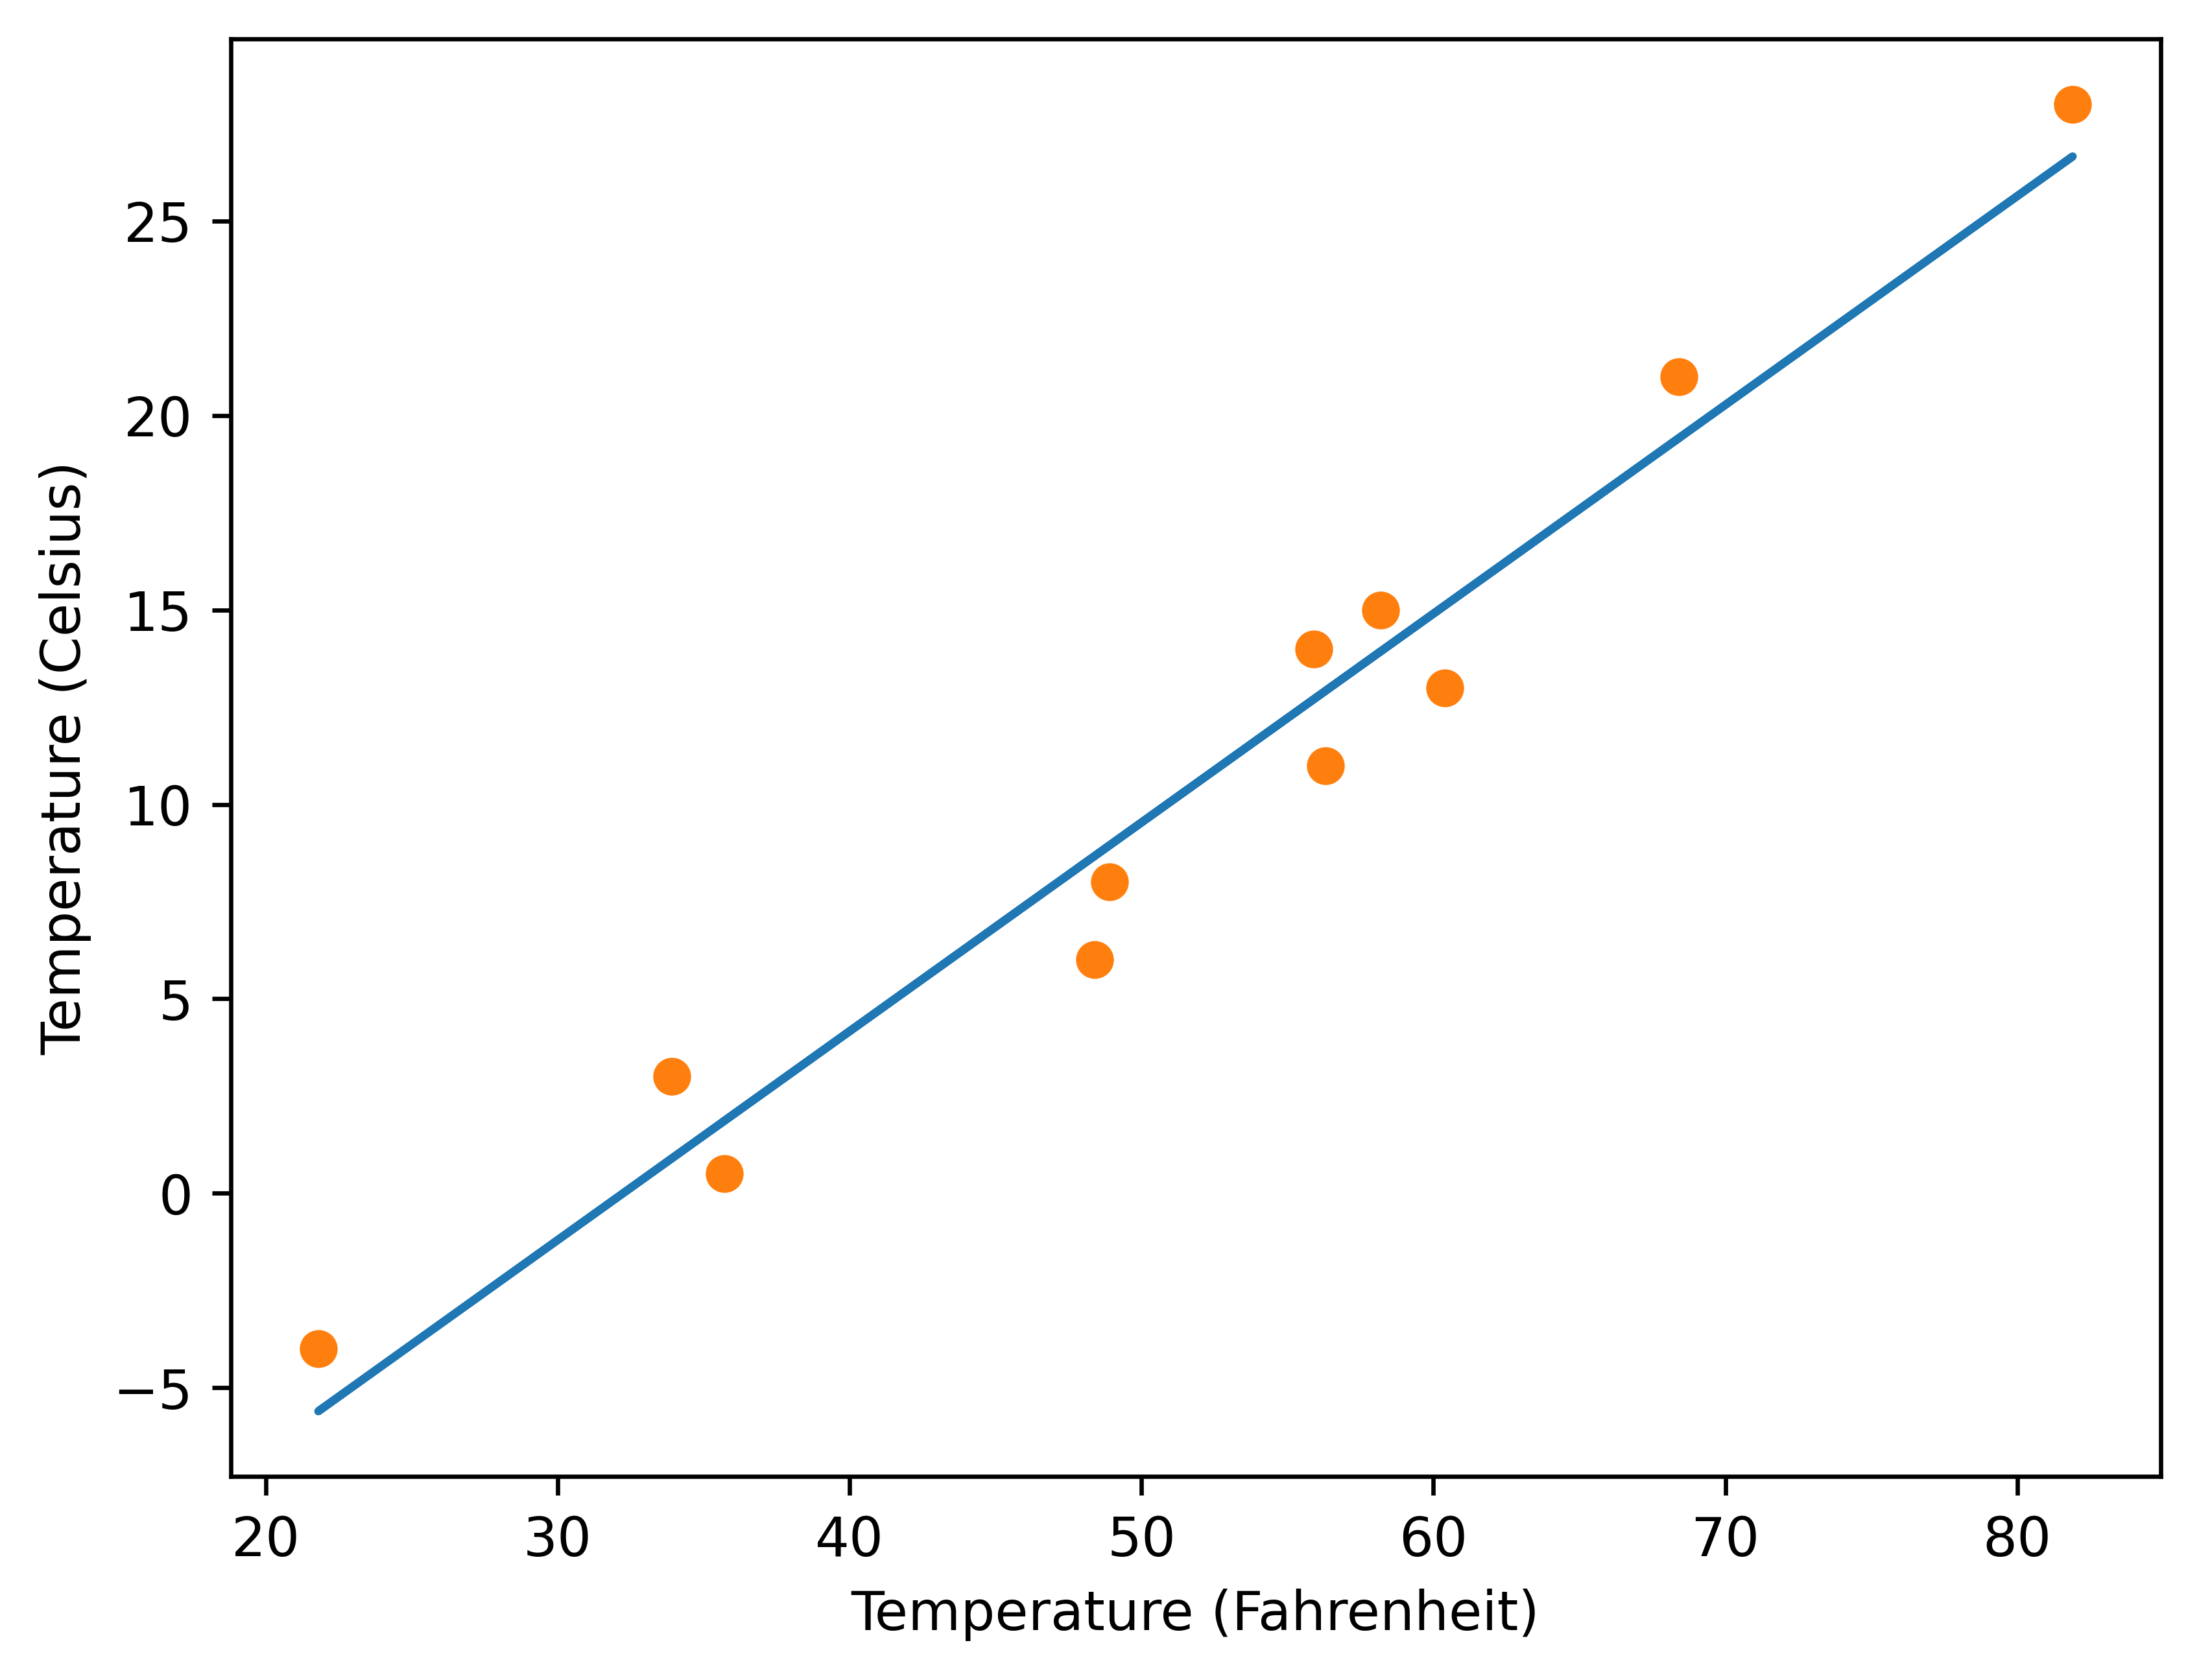

In [17]:
%matplotlib inline
from matplotlib import pyplot as plt

t_p = model(t_un, *params)

fig = plt.figure(dpi=600)
plt.xlabel('Temperature (Fahrenheit)')
plt.ylabel('Temperature (Celsius)')
plt.plot(t_u.numpy(), t_p.detach().numpy())
plt.plot(t_u.numpy(), t_c.numpy(), 'o')

## Компонент AUTOGRAD

In [18]:
params = torch.tensor([1., 0.], requires_grad=True) # вычисление params.grad на каждом из этапов графа вычислений

In [19]:
loss = loss_fn(model(t_u, *params), t_c)
loss.backward() # обратное распространение ошибки (вычисление градиента)

params.grad

tensor([4517.2969,   82.6000])

In [20]:
# явное обнуление градиента, чтобы он не накапливался
if params.grad is not None:
    params.grad.zero_()

Цикл обучения с автоматическим вычислением градиента

In [21]:
def taining_loop_auto(n_epoch, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epoch + 1):
        if params.grad is not None:
            params.grad.zero_()

        t_p = model(t_u, *params) # прямой проход
        loss = loss_fn(t_p, t_c)
        loss.backward()

        # механизм автоматического вычисления градиента игнорирует внутренности блока with (временное решение, потом будут оптимизаторы)
        with torch.no_grad():
            params -= learning_rate * params.grad

        if epoch % 500 == 0:
            print(f'Epoch {epoch}, Loss {float(loss)}')
        
    return params

In [22]:
taining_loop_auto(
    n_epoch = 5000,
    learning_rate = 1e-2,
    params = torch.tensor([1., 0.], requires_grad=True),
    t_u = t_un,
    t_c = t_c)

/tmp/ipykernel_9660/3152434119.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f'Epoch {epoch}, Loss {float(loss)}')


Epoch 500, Loss 7.860115051269531
Epoch 1000, Loss 3.828537940979004
Epoch 1500, Loss 3.092191219329834
Epoch 2000, Loss 2.957697868347168
Epoch 2500, Loss 2.933133840560913
Epoch 3000, Loss 2.9286484718322754
Epoch 3500, Loss 2.9278297424316406
Epoch 4000, Loss 2.9276793003082275
Epoch 4500, Loss 2.927651882171631
Epoch 5000, Loss 2.9276468753814697


tensor([  5.3671, -17.3012], requires_grad=True)

## Оптимизаторы

In [23]:
import torch.optim as optim

In [24]:
dir(optim) # различные алгоритмы оптимизации

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'Muon',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 '_muon',
 'lr_scheduler',
 'swa_utils']

In [25]:
params = torch.tensor([1., 0.], requires_grad=True)
learning_rate = 1e-5
optimizer = optim.SGD([params], lr=learning_rate) # SGD - стохастический градиентный спуск

t_p = model(t_u, *params)
loss = loss_fn(t_p, t_c)

optimizer.zero_grad() # сбрасывание градиента
loss.backward()
optimizer.step()

params

tensor([ 9.5483e-01, -8.2600e-04], requires_grad=True)

In [26]:
def learning_loop_optim(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params) # прямой проход
        
        optimizer.zero_grad()
        loss = loss_fn(t_p, t_c)
        loss.backward()

        optimizer.step()

        if epoch % 500 == 0:
            print(f'Epoch {epoch}, Loss {float(loss)}')
        
    return params

In [27]:
params = torch.tensor([1., 0.], requires_grad=True)
learning_rate = 1e-1 # больше шаг
optimizer = optim.Adam([params], lr=learning_rate) # В Adam скорость обучения задаётся адаптивно и он намного менее чувствителен к масштабу параметров


learning_loop_optim(
    n_epochs = 2000, # меньше эпох
    optimizer = optimizer,
    params = params,
    t_u = t_u, # не так важен масштаб
    t_c = t_c)

Epoch 500, Loss 7.6128997802734375
Epoch 1000, Loss 3.086698293685913
Epoch 1500, Loss 2.9285776615142822
Epoch 2000, Loss 2.9276463985443115


tensor([  0.5367, -17.3021], requires_grad=True)

## Разбиение набора данных

In [28]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples) # перестановка идексов тензора

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([ 7,  9,  3,  8, 10,  1,  4,  5,  6]), tensor([0, 2]))

In [29]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u

def training_loop(n_epochs, optimizer, model, params, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)


        with torch.no_grad():
            val_t_p = model(val_t_u, *params)
            val_loss = loss_fn(val_t_p, val_t_c)
            assert val_loss.requires_grad == False # проверка, что не строим граф вычислений для валидирующей выборки (оптимизация, можно убрать)
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if epoch <= 3 or epoch % 500 == 0:
            print(f'Epoch {epoch}, Training loss {float(train_loss)}, Validation loss {val_loss.item()}')
        
    return params

val_t_un

tensor([3.5700, 5.8200])

In [30]:
params = torch.tensor([1., 0.], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)


training_loop(
    n_epochs = 3000,
    optimizer = optimizer,
    model = model,
    params = params,
    train_t_u = train_t_un, 
    val_t_u = val_t_un,
    train_t_c = train_t_c,
    val_t_c = val_t_c)

Epoch 1, Training loss 87.8122787475586, Validation loss 46.848655700683594
Epoch 2, Training loss 36.99741744995117, Validation loss 27.816133499145508
Epoch 3, Training loss 30.092485427856445, Validation loss 29.78008460998535
Epoch 500, Training loss 7.649576187133789, Validation loss 9.751251220703125
Epoch 1000, Training loss 3.964651346206665, Validation loss 4.240353584289551
Epoch 1500, Training loss 3.3377959728240967, Validation loss 2.692279100418091
Epoch 2000, Training loss 3.2311601638793945, Validation loss 2.177093505859375
Epoch 2500, Training loss 3.2130212783813477, Validation loss 1.9855828285217285
Epoch 3000, Training loss 3.209934949874878, Validation loss 1.910164475440979


tensor([  5.2384, -16.5812], requires_grad=True)

Пробую другую модель

In [31]:
def other_model(t_u, w1, w2, b):
    return w1 * t_u ** 2 + w2 * t_u + b

params = torch.tensor([1., 1., 0.], requires_grad=True)
learning_rate = 1e-4
optimizer = optim.SGD([params], lr=learning_rate)


training_loop(
    n_epochs = 10_000,
    optimizer = optimizer,
    model = other_model,
    params = params,
    train_t_u = train_t_un, 
    val_t_u = val_t_un,
    train_t_c = train_t_c,
    val_t_c = val_t_c)

Epoch 1, Training loss 730.4346923828125, Validation loss 429.91290283203125
Epoch 2, Training loss 409.32958984375, Validation loss 251.98338317871094
Epoch 3, Training loss 231.8556365966797, Validation loss 152.05262756347656
Epoch 500, Training loss 9.89189624786377, Validation loss 15.01648235321045
Epoch 1000, Training loss 7.969987869262695, Validation loss 12.558829307556152
Epoch 1500, Training loss 6.605358123779297, Validation loss 10.744051933288574
Epoch 2000, Training loss 5.636093616485596, Validation loss 9.396425247192383
Epoch 2500, Training loss 4.947319030761719, Validation loss 8.389532089233398
Epoch 3000, Training loss 4.457542419433594, Validation loss 7.632207870483398
Epoch 3500, Training loss 4.108942985534668, Validation loss 7.058553695678711
Epoch 4000, Training loss 3.860506296157837, Validation loss 6.620752334594727
Epoch 4500, Training loss 3.6831347942352295, Validation loss 6.284026145935059
Epoch 5000, Training loss 3.5561790466308594, Validation lo

tensor([ 0.5887, -1.0834, -1.0959], requires_grad=True)

# Модель из NN Pytorch

In [32]:
import torch.nn as nn

In [33]:
t_c = torch.tensor([0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]).unsqueeze(1)
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]).unsqueeze(1)

t_c.shape, t_u.shape

(torch.Size([11, 1]), torch.Size([11, 1]))

In [34]:
n_samples = t_u.shape[0]
n_val = int(0.2 * n_samples)

shuffled_indices = torch.randperm(n_samples) # перестановка идексов тензора

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

In [35]:
linear_model = nn.Linear(1, 1) 
optimizer = optim.SGD(
    linear_model.parameters(),
    lr=1e-2)

In [36]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[0.0648]], requires_grad=True),
 Parameter containing:
 tensor([-0.6783], requires_grad=True)]

In [37]:
def training_loop_nn(n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val, t_c_train, t_c_val):
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train)
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val)
        loss_val = loss_fn(t_p_val, t_c_val)

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        if epoch <= 3 or epoch % 1000 == 0:
            print(f'Epoch {epoch}, Training loss {float(loss_train)}, Validation loss {loss_val.item()}')

In [38]:
training_loop_nn(
    n_epochs = 3000,
    optimizer = optimizer,
    model = linear_model,
    loss_fn = nn.MSELoss(), # аналогична описанной ранее вручную
    t_u_train = t_un_train,
    t_u_val = t_un_val,
    t_c_train = t_c_train,
    t_c_val = t_c_val)
print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 211.68734741210938, Validation loss 108.4724349975586
Epoch 2, Training loss 47.4051513671875, Validation loss 39.78512191772461
Epoch 3, Training loss 28.09691619873047, Validation loss 37.312557220458984
Epoch 1000, Training loss 4.737331390380859, Validation loss 1.0895518064498901
Epoch 2000, Training loss 3.0003082752227783, Validation loss 2.8871660232543945
Epoch 3000, Training loss 2.856447458267212, Validation loss 4.498434066772461

Parameter containing:
tensor([[5.5681]], requires_grad=True)
Parameter containing:
tensor([-18.6952], requires_grad=True)


Замена линейной модели нейронной сетью

In [39]:
from collections import OrderedDict
seq_model = nn.Sequential(
    OrderedDict([
        ('hidden_linear', nn.Linear(1, 13)),
        ('hidden_activation', nn.Tanh()),
        ('output_activation', nn.Linear(13, 1))
]))
seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=13, bias=True)
  (hidden_activation): Tanh()
  (output_activation): Linear(in_features=13, out_features=1, bias=True)
)

In [40]:
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [41]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

hidden_linear.weight torch.Size([13, 1])
hidden_linear.bias torch.Size([13])
output_activation.weight torch.Size([1, 13])
output_activation.bias torch.Size([1])


In [42]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3)
training_loop_nn(
    n_epochs = 3000,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.MSELoss(),
    t_u_train = t_un_train,
    t_u_val = t_un_val,
    t_c_train = t_c_train,
    t_c_val = t_c_val)
print('output', seq_model(t_un_val))
print('answer', t_c_val)
print('hidden', seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 191.54200744628906, Validation loss 99.75225830078125
Epoch 2, Training loss 185.46649169921875, Validation loss 97.04499816894531
Epoch 3, Training loss 179.67933654785156, Validation loss 94.49998474121094
Epoch 1000, Training loss 4.211652755737305, Validation loss 1.5337976217269897
Epoch 2000, Training loss 3.7813191413879395, Validation loss 0.14619746804237366
Epoch 3000, Training loss 2.4967658519744873, Validation loss 1.356135606765747
output tensor([[-3.1723],
        [10.7228]], grad_fn=<AddmmBackward0>)
answer tensor([[-4.],
        [14.]])
hidden tensor([[-1.6094e+01],
        [ 5.3242e-03],
        [-2.5354e+01],
        [ 5.8150e-03],
        [ 1.9724e+01],
        [ 1.5680e+00],
        [ 2.4617e+01],
        [-2.0802e+01],
        [-2.2227e-01],
        [ 1.1742e+01],
        [-5.0609e-04],
        [ 2.4961e+01],
        [ 6.2199e-01]])


Проверка новой модели

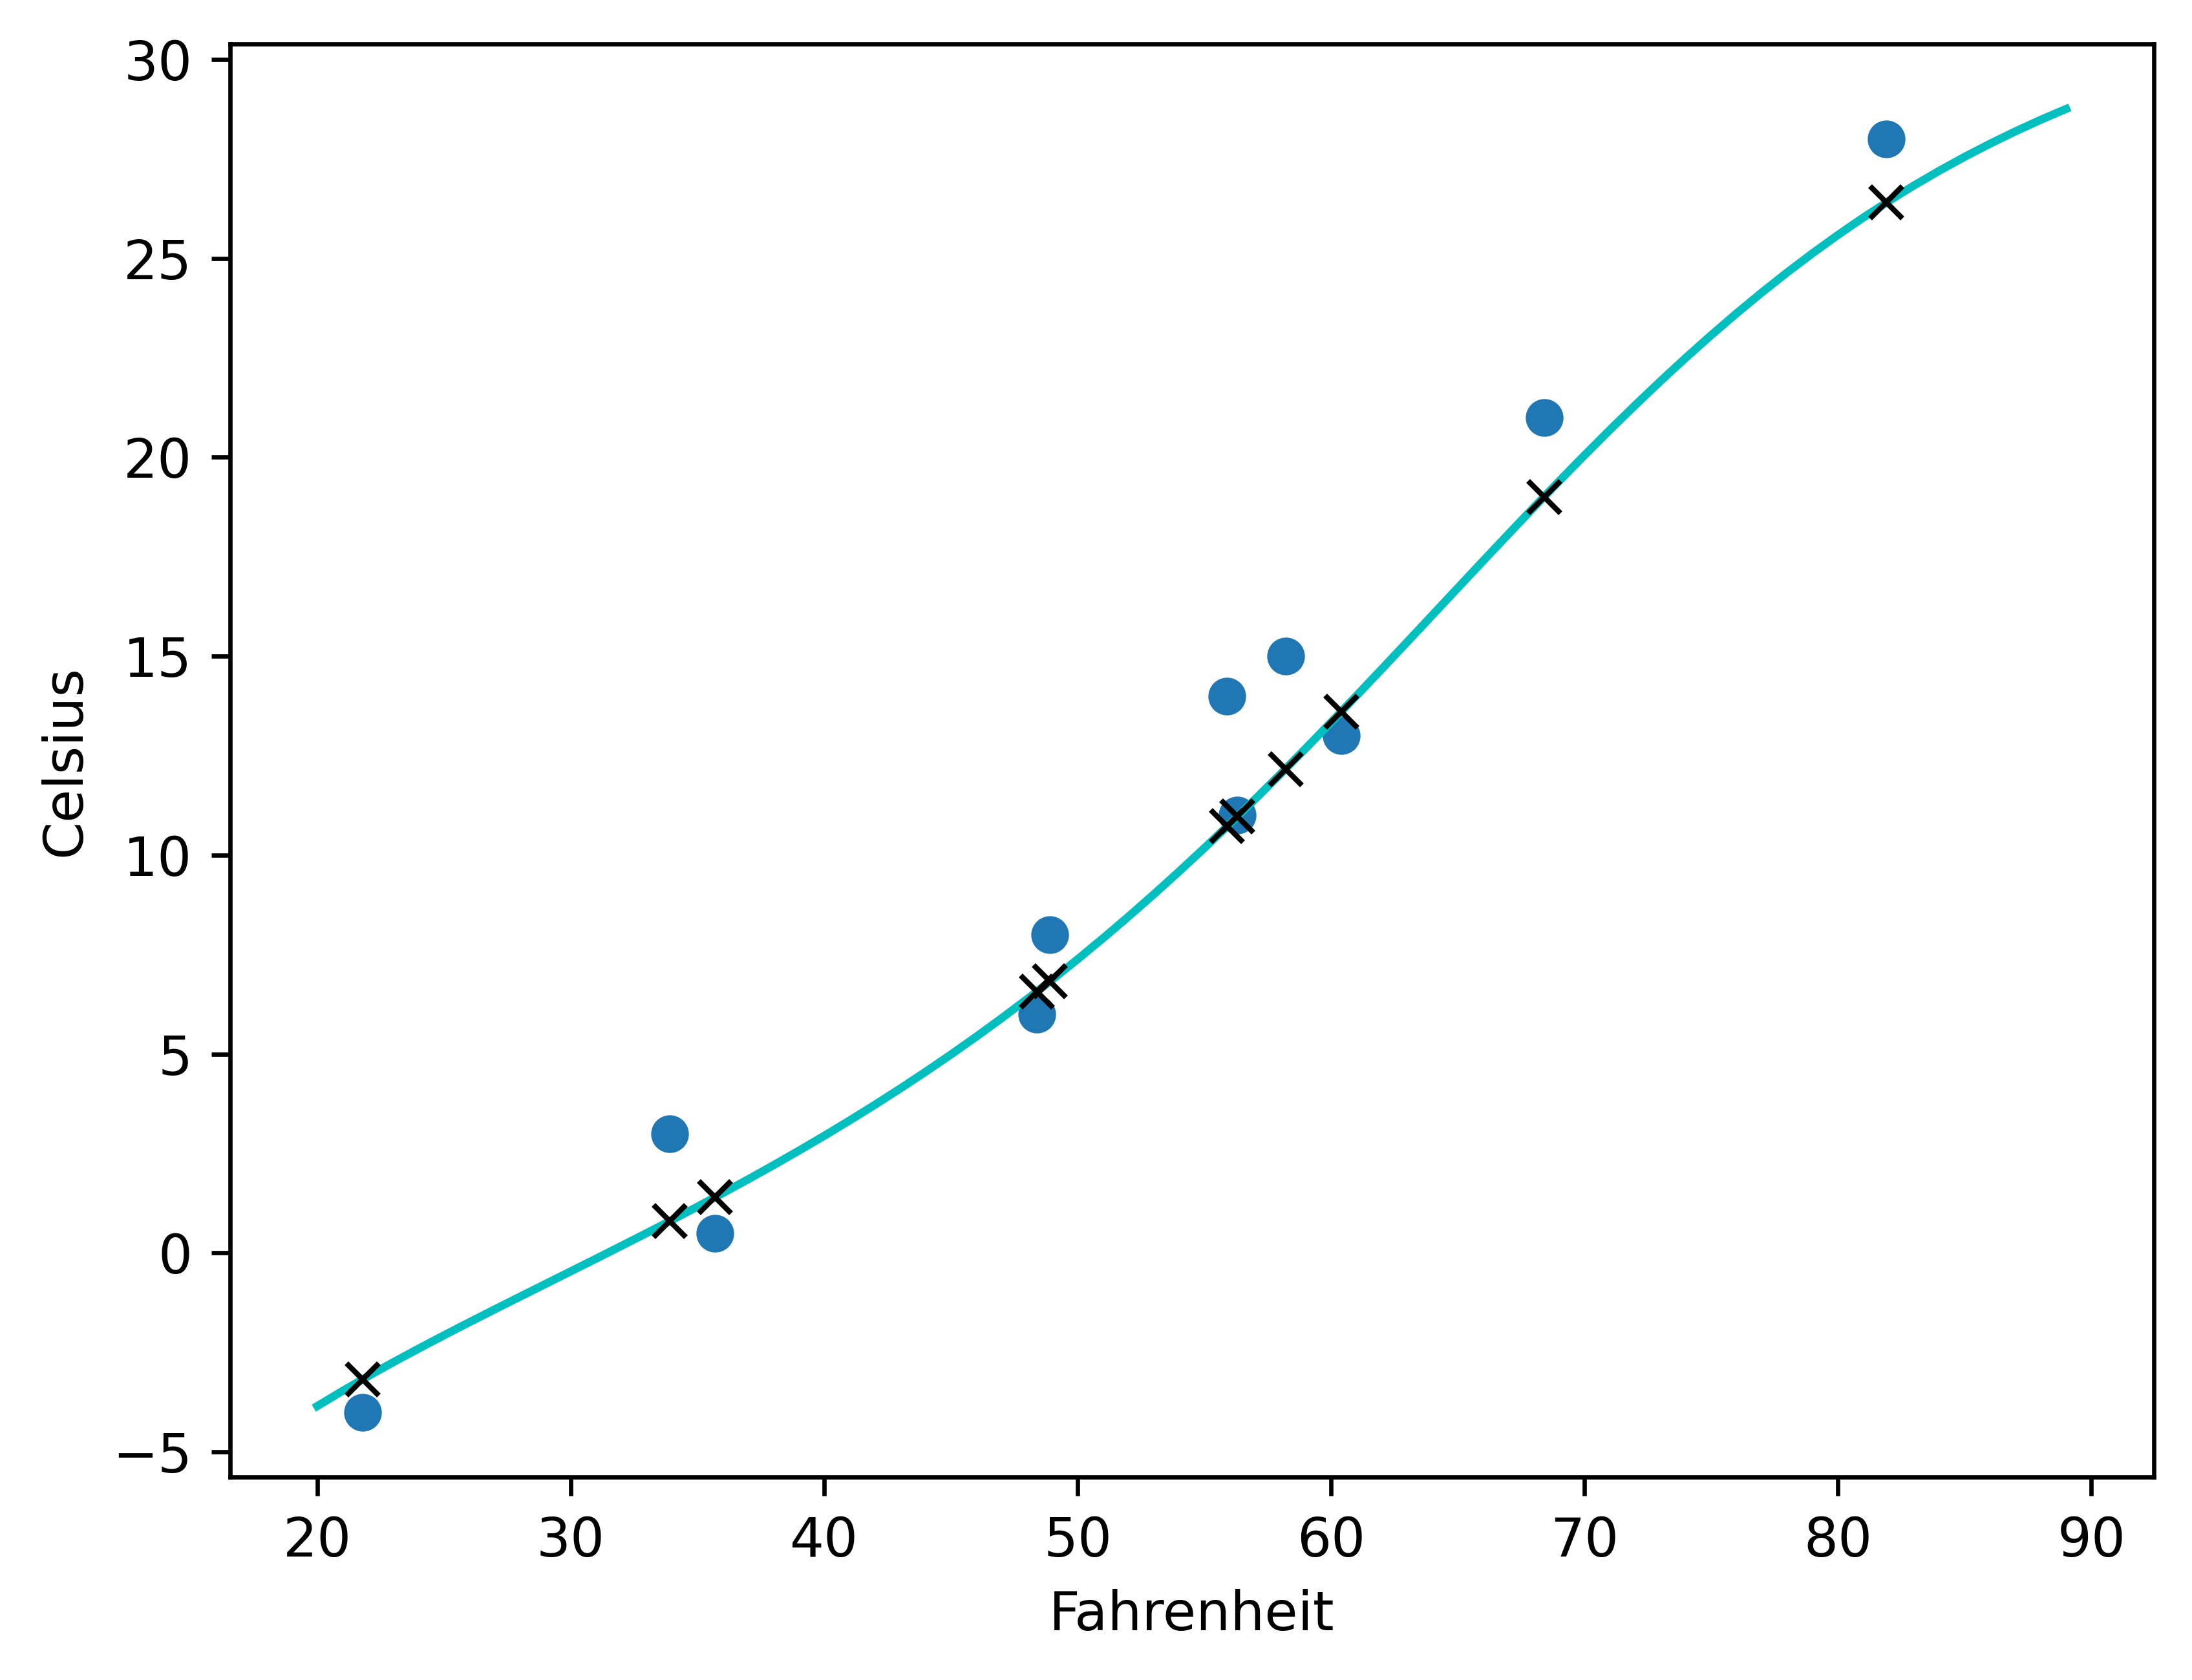

In [43]:
t_range = torch.arange(20., 90.).unsqueeze(1)

fig = plt.figure(dpi=600)
plt.xlabel('Fahrenheit')
plt.ylabel('Celsius')
plt.plot(t_u.numpy(), t_c.numpy(), 'o')
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), 'c-')
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), 'kx')